In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('co2_monthly_1987_2026_clean.csv')
df = df.sort_values(['Year', 'Month']).reset_index(drop=True)

In [ ]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))

In [ ]:
df['time_index'] = np.arange(len(df))

In [ ]:
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

In [ ]:
for lag in [1, 2, 3, 6, 12]:
    df[f'CO2_lag{lag}'] = df['Total_CO2'].shift(lag)

In [ ]:
df['roll_mean_3']  = df['Total_CO2'].shift(1).rolling(3).mean()
df['roll_mean_12'] = df['Total_CO2'].shift(1).rolling(12).mean()

In [ ]:
df = df.dropna().reset_index(drop=True)

In [ ]:
features = ['time_index', 'month_sin', 'month_cos',
            'CO2_lag1', 'CO2_lag2', 'CO2_lag3', 'CO2_lag6', 'CO2_lag12',
            'roll_mean_3', 'roll_mean_12']

X, y = df[features], df['Total_CO2']

In [ ]:
split_idx = df[(df['Year'] == 2024) & (df['Month'] == 1)].index[0]
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

val_size = 24
X_tr, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
y_tr, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]
print(f"Fit: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_test)}")

Fit: 408 | Val: 24 | Test: 27


In [ ]:
tscv = TimeSeriesSplit(n_splits=5, test_size=24)


In [ ]:
param_grid = [
    dict(max_depth=2, learning_rate=0.03, min_child_weight=5,  reg_lambda=1.0,  reg_alpha=0.0),
    dict(max_depth=2, learning_rate=0.05, min_child_weight=10, reg_lambda=5.0,  reg_alpha=0.5),
    dict(max_depth=3, learning_rate=0.03, min_child_weight=10, reg_lambda=5.0,  reg_alpha=0.5),
    dict(max_depth=3, learning_rate=0.05, min_child_weight=20, reg_lambda=10.0, reg_alpha=1.0),
    dict(max_depth=4, learning_rate=0.03, min_child_weight=20, reg_lambda=10.0, reg_alpha=1.0),
]

In [ ]:
tscv = TimeSeriesSplit(n_splits=5, test_size=24)
best_mape, best_params = np.inf, None

for p in param_grid:
    fold_mapes = []
    for tr_idx, val_idx in tscv.split(X_train):
        m = xgb.XGBRegressor(**p, n_estimators=2000, subsample=0.8, colsample_bytree=0.8,
                             early_stopping_rounds=50, random_state=42, verbosity=0)
        m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx],
              eval_set=[(X_train.iloc[val_idx], y_train.iloc[val_idx])], verbose=False)
        pred = m.predict(X_train.iloc[val_idx])
        fold_mapes.append(np.mean(np.abs((y_train.iloc[val_idx] - pred) / y_train.iloc[val_idx])) * 100)
    cv_mape = np.mean(fold_mapes)
    print(f"{p}  ->  CV MAPE {cv_mape:.3f}%")
    if cv_mape < best_mape:
        best_mape, best_params = cv_mape, p

print(f"\nBest: {best_params}  (CV MAPE {best_mape:.3f}%)")

{'max_depth': 2, 'learning_rate': 0.03, 'min_child_weight': 5, 'reg_lambda': 1.0, 'reg_alpha': 0.0}  ->  CV MAPE 2.836%
{'max_depth': 2, 'learning_rate': 0.05, 'min_child_weight': 10, 'reg_lambda': 5.0, 'reg_alpha': 0.5}  ->  CV MAPE 2.823%
{'max_depth': 3, 'learning_rate': 0.03, 'min_child_weight': 10, 'reg_lambda': 5.0, 'reg_alpha': 0.5}  ->  CV MAPE 2.850%
{'max_depth': 3, 'learning_rate': 0.05, 'min_child_weight': 20, 'reg_lambda': 10.0, 'reg_alpha': 1.0}  ->  CV MAPE 2.826%
{'max_depth': 4, 'learning_rate': 0.03, 'min_child_weight': 20, 'reg_lambda': 10.0, 'reg_alpha': 1.0}  ->  CV MAPE 2.833%

Best: {'max_depth': 2, 'learning_rate': 0.05, 'min_child_weight': 10, 'reg_lambda': 5.0, 'reg_alpha': 0.5}  (CV MAPE 2.823%)


In [ ]:
probe = xgb.XGBRegressor(**best_params, n_estimators=2000, subsample=0.8, colsample_bytree=0.8,
                         early_stopping_rounds=50, random_state=42, verbosity=0)
probe.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
best_n = probe.best_iteration + 1
print(f"Trees chosen by early stopping: {best_n}")

model = xgb.XGBRegressor(**best_params, n_estimators=best_n, subsample=0.8,
                         colsample_bytree=0.8, random_state=42, verbosity=0)
model.fit(X_train, y_train)

Trees chosen by early stopping: 221


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=221,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
def show_metrics(yt, yp, label):
    print(f"\n  {label}")
    print(f"    MAE : {mean_absolute_error(yt, yp):>8.2f}  Mt CO₂")
    print(f"    RMSE: {mean_squared_error(yt, yp)**0.5:>8.2f}  Mt CO₂")
    print(f"    MAPE: {np.mean(np.abs((yt - yp) / yt)) * 100:>8.2f} %")
    print(f"    R²  : {r2_score(yt, yp):>8.4f}")

p_train = model.predict(X_train)
p_test  = model.predict(X_test)

show_metrics(y_train, p_train, "TRAIN")
show_metrics(y_test,  p_test,  "TEST (2024–2026)")
print(f"\nGap (train R² − test R²): {r2_score(y_train, p_train) - r2_score(y_test, p_test):.4f}")


  TRAIN
    MAE :   282.09  Mt CO₂
    RMSE:   379.27  Mt CO₂
    MAPE:     1.91 %
    R²  :   0.9945

  TEST (2024–2026)
    MAE :   445.52  Mt CO₂
    RMSE:   521.55  Mt CO₂
    MAPE:     2.24 %
    R²  :   0.6897

Gap (train R² − test R²): 0.3048


In [ ]:
train_dates = df.loc[:split_idx-1, 'Date']
test_dates  = df.loc[split_idx:,   'Date'].reset_index(drop=True)
residuals   = y_test.values - p_test

In [ ]:
out = df.loc[split_idx:, ['Year', 'Month']].copy()
out['Actual']    = y_test.values
out['Predicted'] = p_test.round(2)
out['Error']     = residuals.round(2)
out['AbsPctErr'] = (np.abs(residuals / y_test.values) * 100).round(3)
out.to_csv('xgboost_datetime_predictions.csv', index=False)

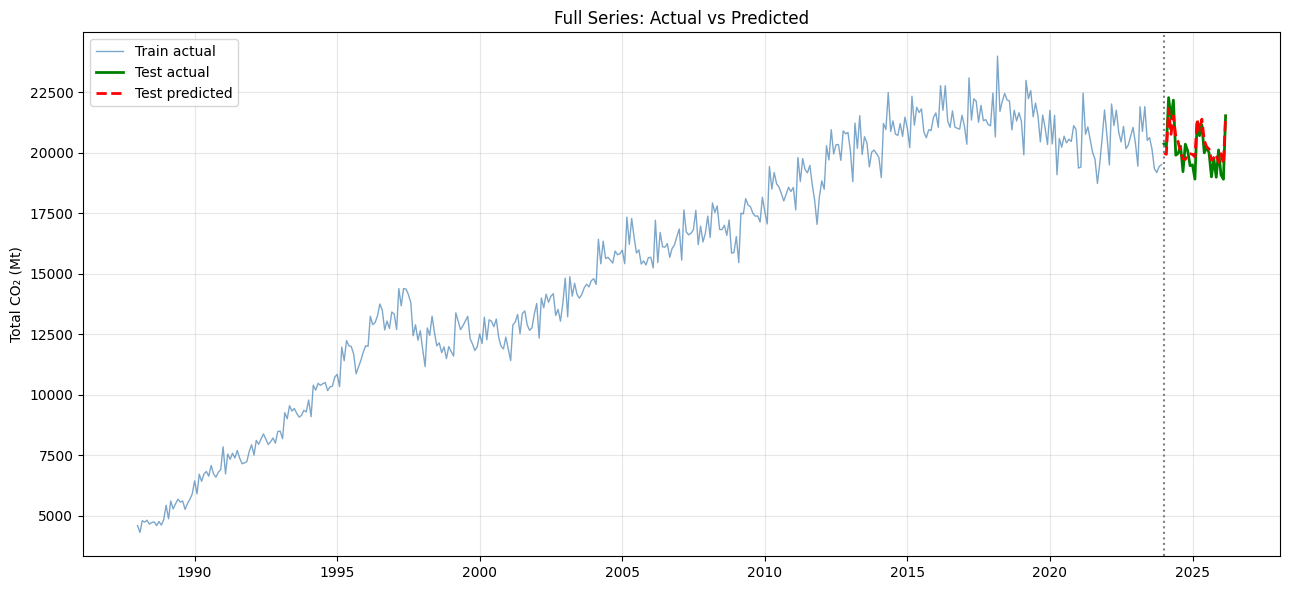

In [ ]:
train_dates = df.loc[:split_idx-1, 'Date']
test_dates  = df.loc[split_idx:,   'Date'].reset_index(drop=True)

plt.figure(figsize=(13, 6))
plt.plot(train_dates, y_train.values, color='steelblue', lw=1, alpha=0.7, label='Train actual')
plt.plot(test_dates,  y_test.values,  color='green', lw=2, label='Test actual')
plt.plot(test_dates,  p_test, color='red', lw=2, ls='--', label='Test predicted')
plt.axvline(test_dates.iloc[0], color='gray', ls=':')
plt.title('Full Series: Actual vs Predicted')
plt.ylabel('Total CO₂ (Mt)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('plot1_full_series.png', dpi=150)
plt.show()

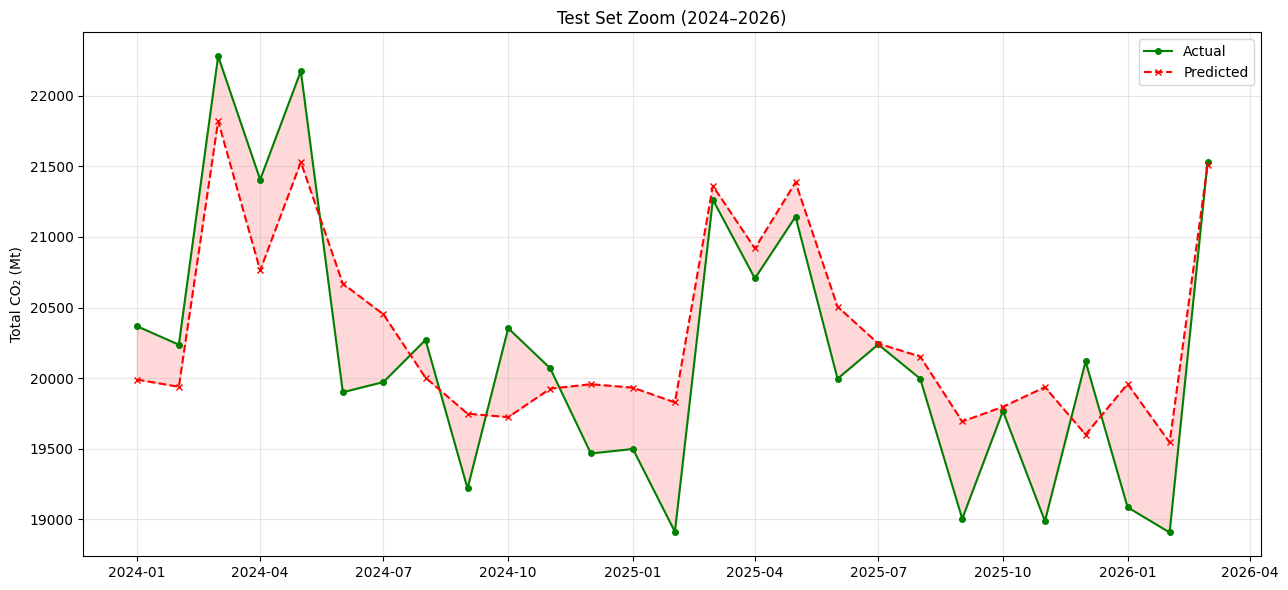

In [ ]:
test_dates = df.loc[split_idx:, 'Date'].reset_index(drop=True)

plt.figure(figsize=(13, 6))
plt.plot(test_dates, y_test.values, color='green', marker='o', ms=4, label='Actual')
plt.plot(test_dates, p_test, color='red', marker='x', ms=5, ls='--', label='Predicted')
plt.fill_between(test_dates, y_test.values, p_test, alpha=0.15, color='red')
plt.title('Test Set Zoom (2024–2026)')
plt.ylabel('Total CO₂ (Mt)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('plot2_test_zoom.png', dpi=150)
plt.show()

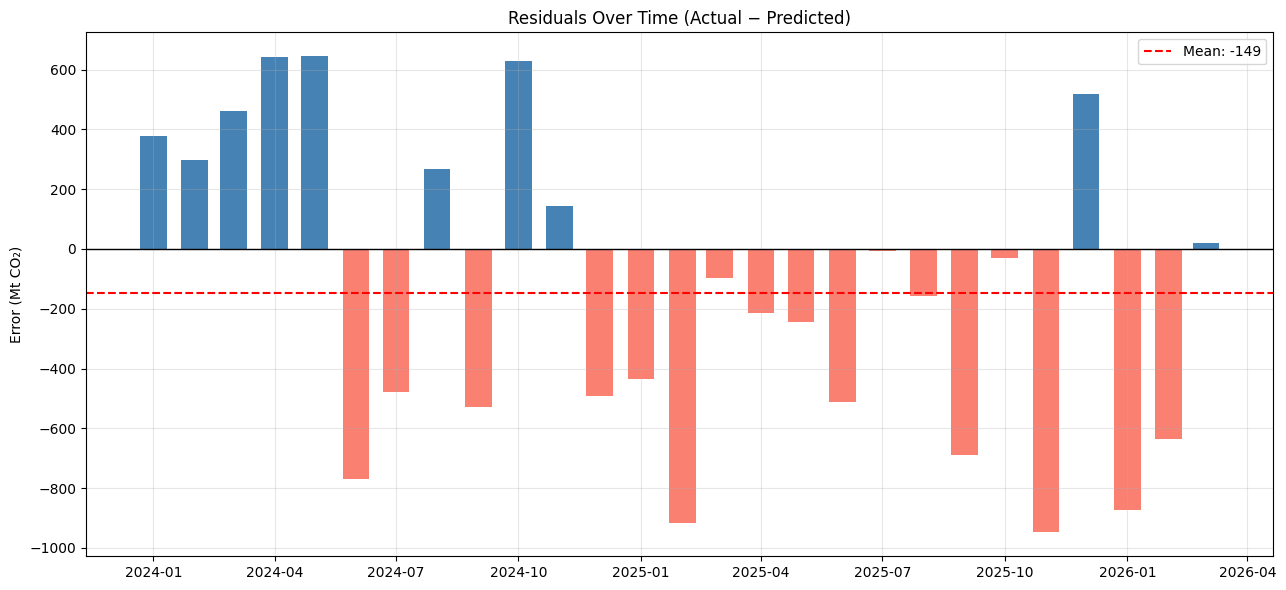

In [ ]:
test_dates = df.loc[split_idx:, 'Date'].reset_index(drop=True)
residuals  = y_test.values - p_test

plt.figure(figsize=(13, 6))
plt.bar(test_dates, residuals,
        color=['steelblue' if r >= 0 else 'salmon' for r in residuals], width=20)
plt.axhline(0, color='black', lw=1)
plt.axhline(residuals.mean(), color='red', ls='--', label=f'Mean: {residuals.mean():.0f}')
plt.title('Residuals Over Time (Actual − Predicted)')
plt.ylabel('Error (Mt CO₂)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('plot3_residuals.png', dpi=150)
plt.show()

### Residual Distribution

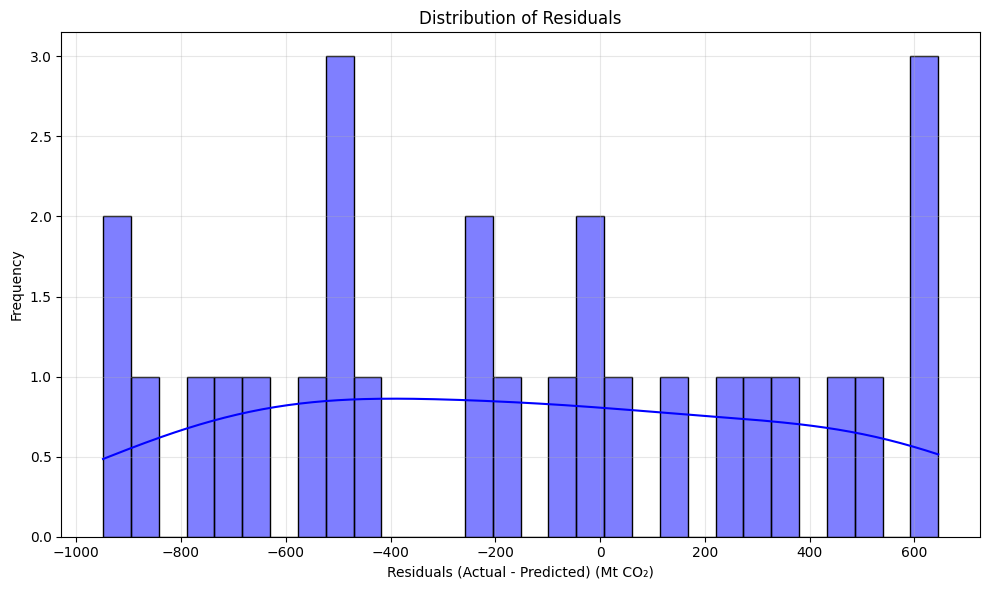

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color='blue')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted) (Mt CO₂)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot5_residuals_distribution.png', dpi=150)
plt.show()

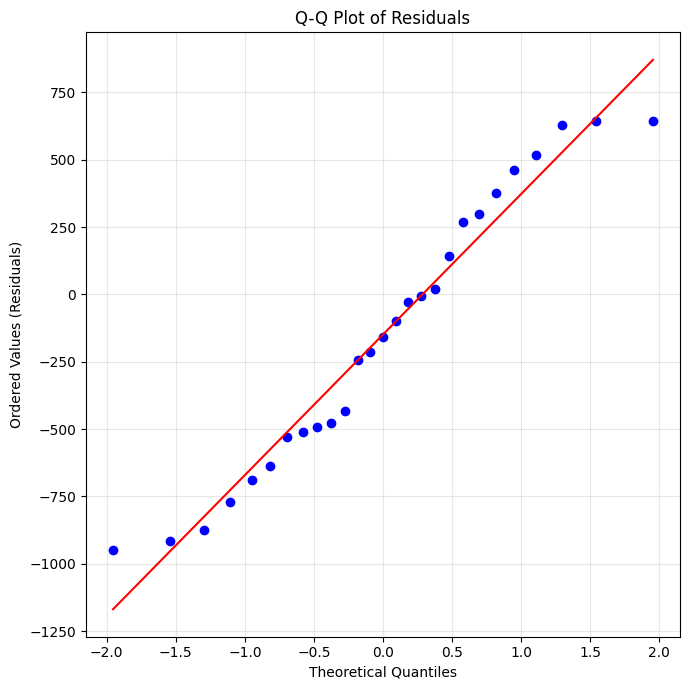

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values (Residuals)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot6_residuals_qq_plot.png', dpi=150)
plt.show()

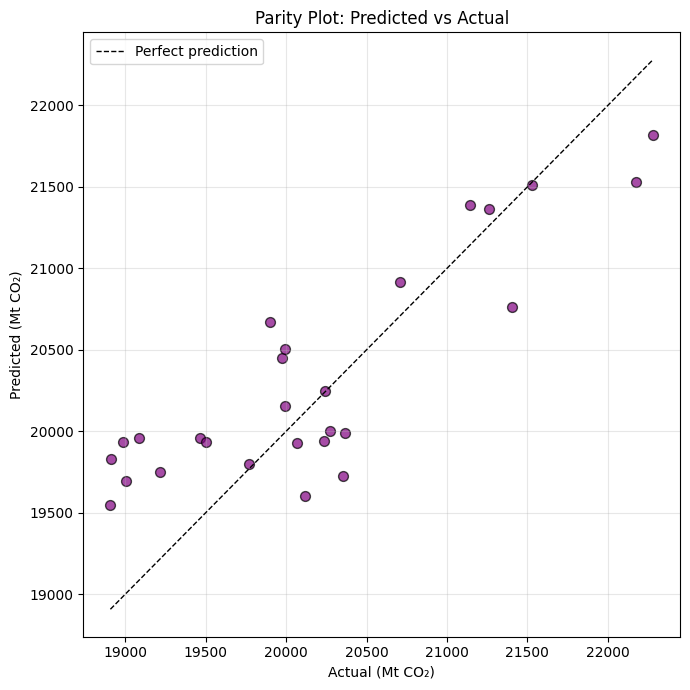

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, p_test, color='purple', alpha=0.7, edgecolor='k', s=50)
lims = [min(y_test.min(), p_test.min()), max(y_test.max(), p_test.max())]
plt.plot(lims, lims, 'k--', lw=1, label='Perfect prediction')
plt.xlabel('Actual (Mt CO₂)')
plt.ylabel('Predicted (Mt CO₂)')
plt.title('Parity Plot: Predicted vs Actual')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('plot4_parity.png', dpi=150)
plt.show()

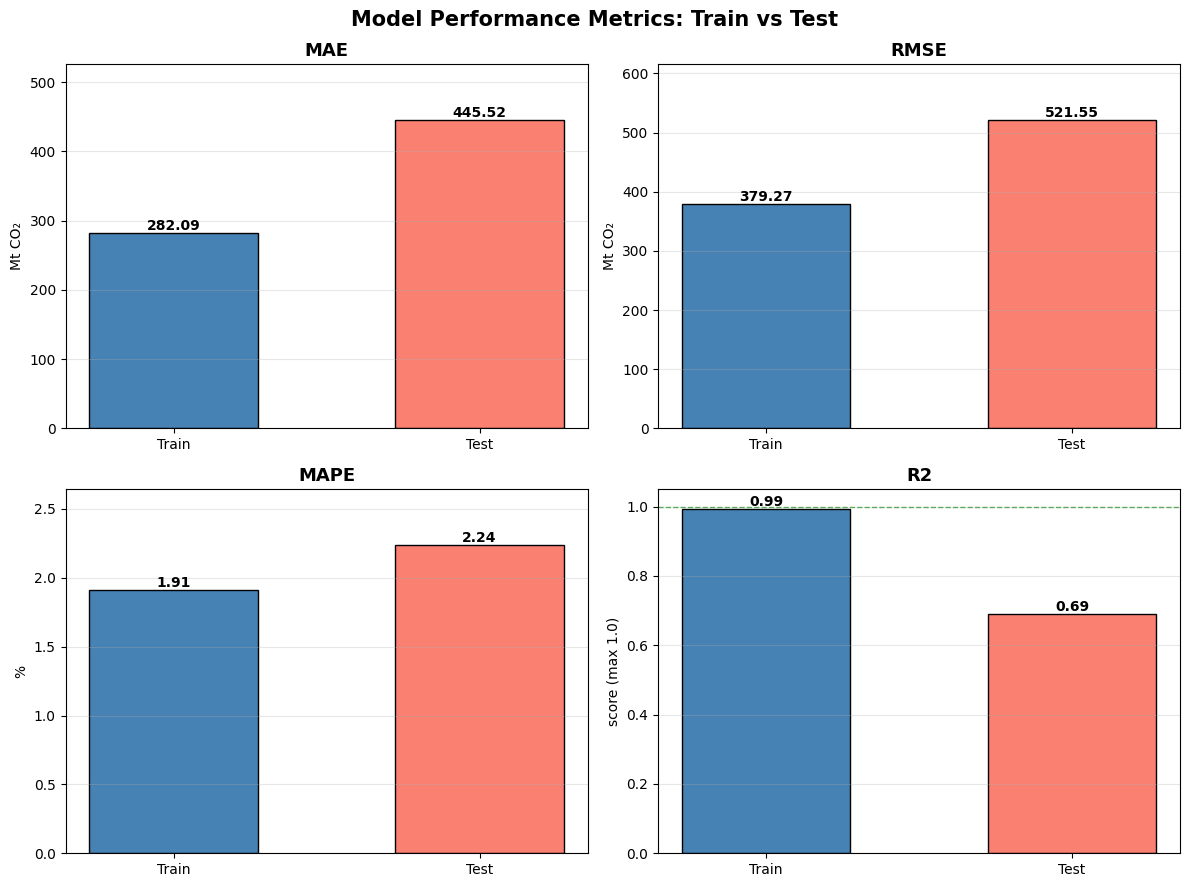

In [ ]:
metrics = ['MAE', 'RMSE', 'MAPE', 'R2']
units   = ['Mt CO₂', 'Mt CO₂', '%', 'score (max 1.0)']

# Calculate metrics for train set
tr = {
    'MAE': mean_absolute_error(y_train, p_train),
    'RMSE': mean_squared_error(y_train, p_train)**0.5,
    'MAPE': np.mean(np.abs((y_train - p_train) / y_train)) * 100,
    'R2': r2_score(y_train, p_train)
}

# Calculate metrics for test set
te = {
    'MAE': mean_absolute_error(y_test, p_test),
    'RMSE': mean_squared_error(y_test, p_test)**0.5,
    'MAPE': np.mean(np.abs((y_test - p_test) / y_test)) * 100,
    'R2': r2_score(y_test, p_test)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Model Performance Metrics: Train vs Test', fontsize=15, fontweight='bold')

for ax, met, unit in zip(axes.flat, metrics, units):
    vals = [tr[met], te[met]]
    bars = ax.bar(['Train', 'Test'], vals, color=['steelblue', 'salmon'],
                  width=0.55, edgecolor='k')
    ax.set_title(met, fontsize=13, fontweight='bold')
    ax.set_ylabel(unit)
    ax.grid(alpha=0.3, axis='y')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.2f}',
                ha='center', va='bottom', fontweight='bold')
    if met == 'R2':
        ax.set_ylim(0, 1.05)
        ax.axhline(1.0, color='green', ls='--', lw=1, alpha=0.6)
    else:
        ax.set_ylim(0, max(vals) * 1.18)

plt.tight_layout()
plt.savefig('metrics_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
naive = df['Total_CO2'].shift(12).iloc[split_idx:].values   # same month, last year
m = ~np.isnan(naive)
print(f"Seasonal-naive  MAPE={np.mean(np.abs((y_test.values[m]-naive[m])/y_test.values[m]))*100:5.2f}%  "
      f"R²={r2_score(y_test.values[m], naive[m]):.4f}")
print(f"XGBoost         MAPE={np.mean(np.abs((y_test-p_test)/y_test))*100:5.2f}%  "
      f"R²={r2_score(y_test, p_test):.4f}")

Seasonal-naive  MAPE= 2.60%  R²=0.5261
XGBoost         MAPE= 2.24%  R²=0.6897
